# 7th June 2026

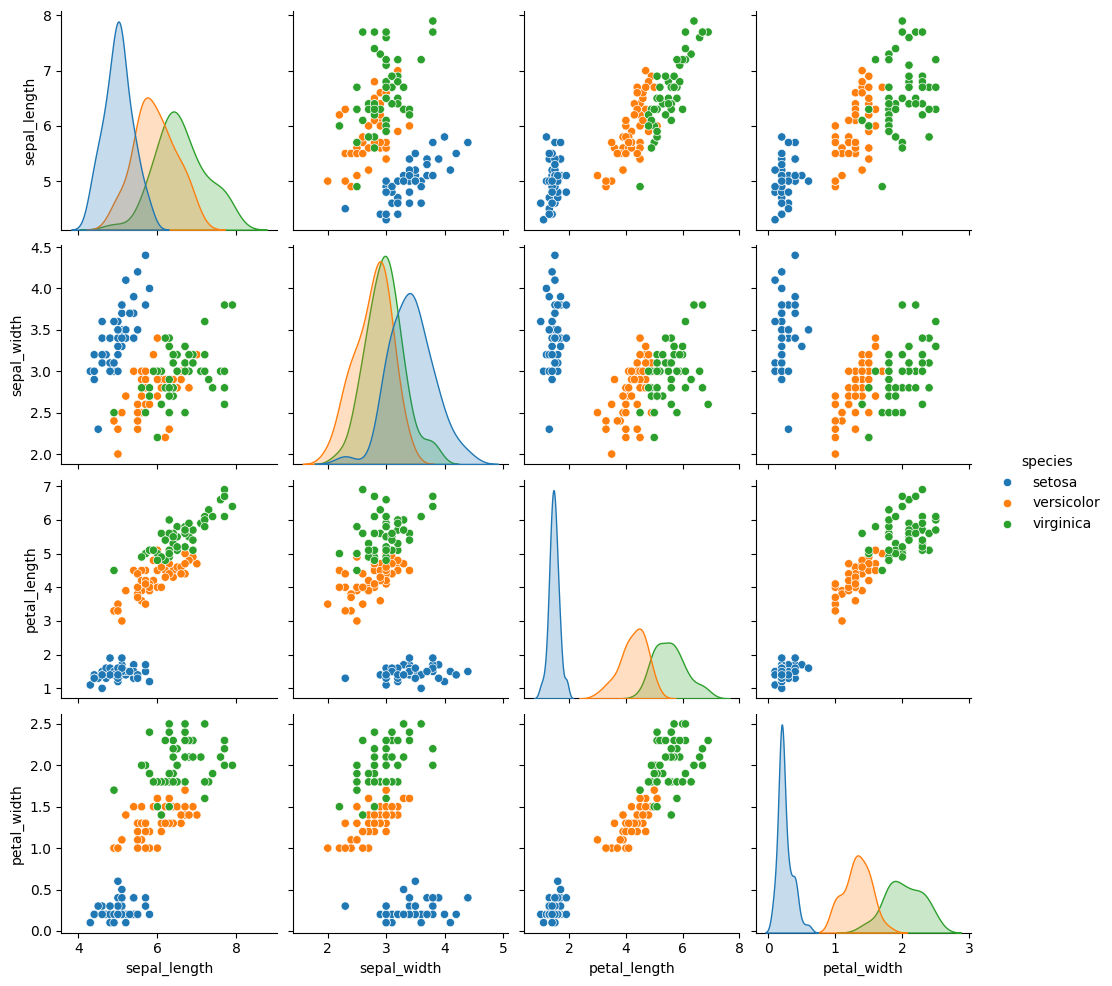

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = sns.load_dataset("iris")
sns.pairplot(df,hue="species")
plt.show()

In [2]:
data = pd.read_csv(r"C:\Users\barat\Downloads\House Price Prediction Dataset.csv")
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


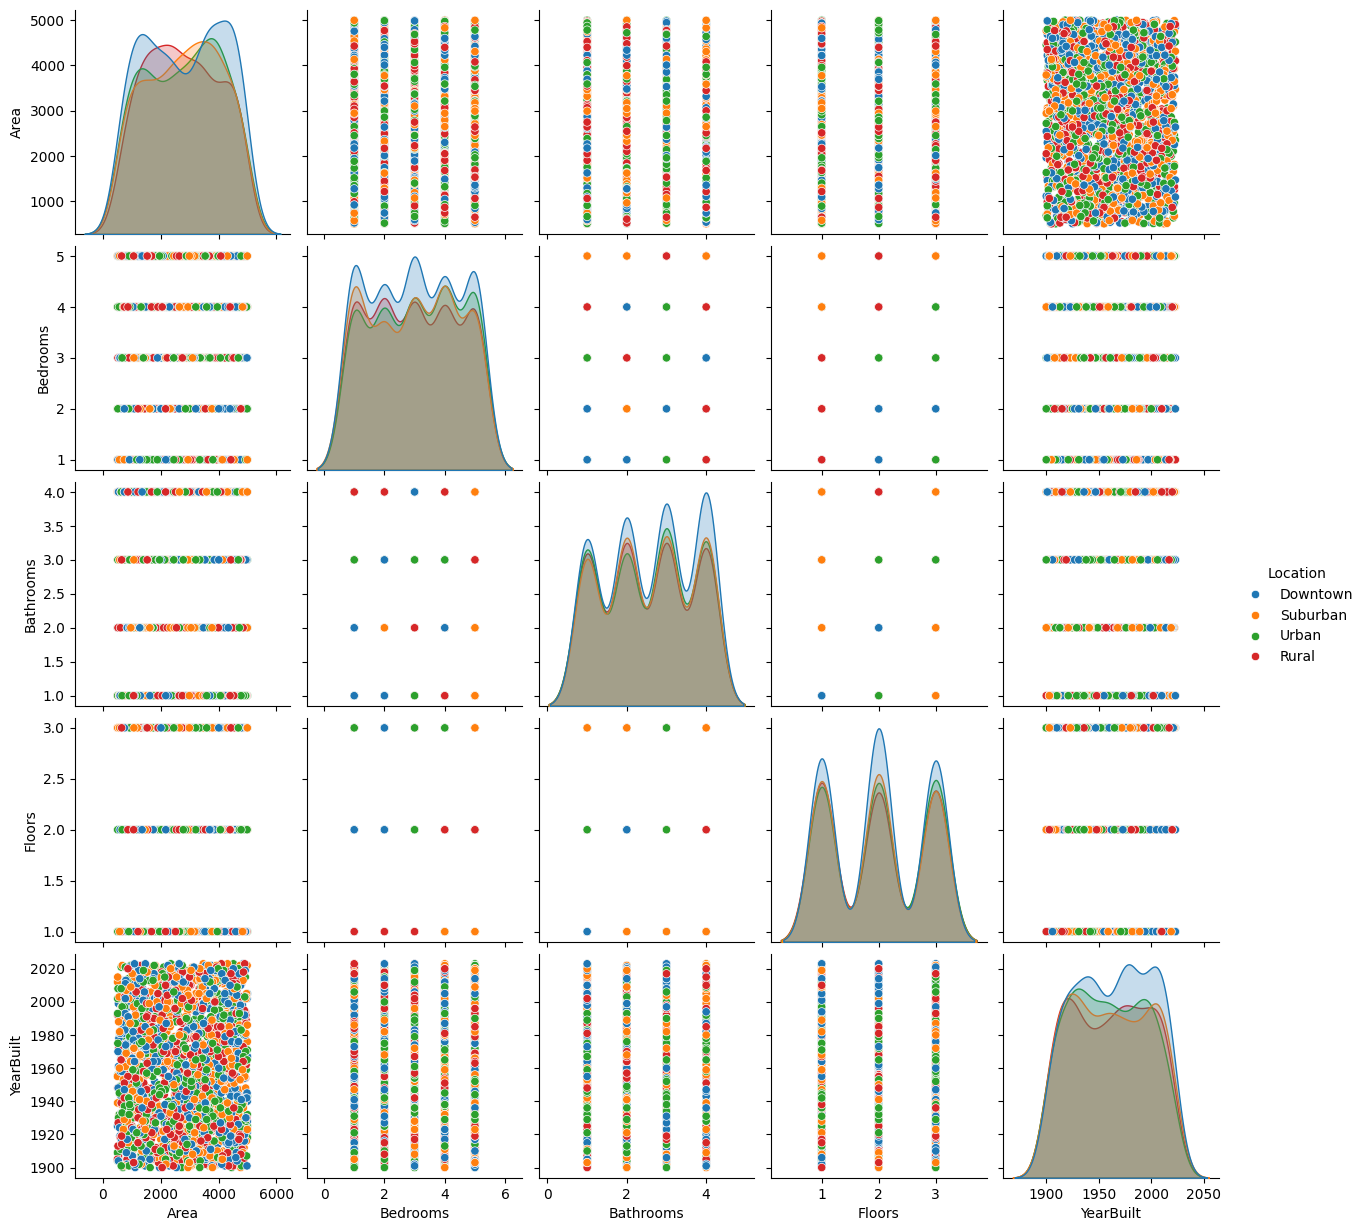

In [7]:
data1 = data.drop(["Id", "Price"], axis=1)
sns.pairplot(data1,hue="Location")
plt.show()

In [9]:
df.drop("species", axis=1, inplace=True)
df.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [13]:
df=pd.DataFrame()
df["X"]=[1,2,3,4,5]
df["Y"]=[10,50,35,40,60]
df.corr()

,X,Y
X,1.000000,0.755263
Y,0.755263,1.000000


In [15]:
df=pd.DataFrame()
df["X"]=[1,2,3,4,5]
df["Y"]=[10,50,35,40,60]
df["X - X.mean"]=df["X"]-df["X"].mean()
df["Y - Y.mean"]=df["Y"]-df["Y"].mean()
df["product"]=(df["X"]-df["X"].mean())*(df["Y"]-df["Y"].mean())
df["X - X.mean"]**2
df["Y - Y.mean"]**2
numerator=df["product"].sum()
denominator=((df["X - X.mean"]**2).sum()*(df["Y - Y.mean"]**2).sum())**0.5
correlation=numerator/denominator
correlation

np.float64(0.7552632224670202)

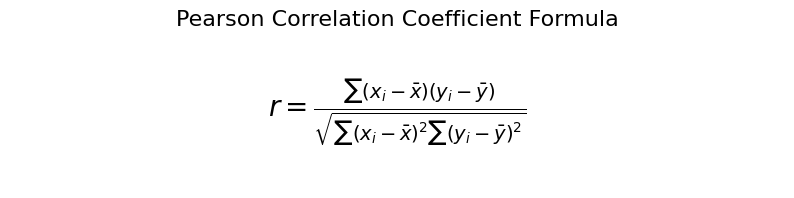

In [17]:
import matplotlib.pyplot as plt

formula = r"$r=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum (x_i-\bar{x})^2 \sum (y_i-\bar{y})^2}}$"

plt.figure(figsize=(10, 2))
plt.text(0.5, 0.5, formula, fontsize=20, ha='center', va='center')
plt.title("Pearson Correlation Coefficient Formula", fontsize=16)
plt.axis('off')
plt.show()

In [23]:
from sklearn.decomposition import PCA
df = sns.load_dataset("iris")
species = df["species"]
df = df.drop("species", axis=1)

pca = PCA(n_components=2)
decomposed = pd.DataFrame(pca.fit_transform(df), columns=["P1", "P2"])
np.cumsum(pca.explained_variance_ratio_)

array([0.92461872, 0.97768521])

In [24]:
decomposed

,P1,P2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755
...,...,...
145,1.944110,0.187532
146,1.527167,-0.375317
147,1.764346,0.078859
148,1.900942,0.116628


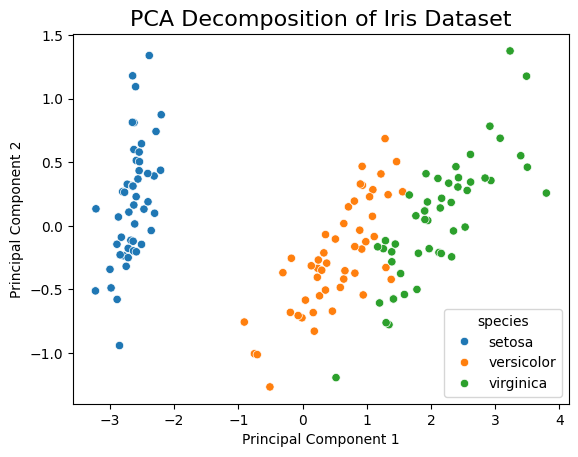

In [26]:
sns.scatterplot(x=decomposed["P1"], y=decomposed["P2"], hue=species)
plt.title("PCA Decomposition of Iris Dataset", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [28]:
from statsmodels.multivariate.manova import MANOVA
df = pd.DataFrame()
df["Method"]=["A","A","A","B","B","B"]
df["Score1"]=[85,90,88,78,82,80]
df["Score2"]=[92,95,91,85,88,84]
manova = MANOVA.from_formula('Score1 + Score2 ~ Method', data=df)
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept          Value   Num DF Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda    0.0006 2.0000 3.0000 2386.2910 0.0000
         Pillai's trace    0.9994 2.0000 3.0000 2386.2910 0.0000
 Hotelling-Lawley trace 1590.8607 2.0000 3.0000 2386.2910 0.0000
    Roy's greatest root 1590.8607 2.0000 3.0000 2386.2910 0.0000
----------------------------------------------------------------
                                                                
-----------------------------------------------------------------
          Method          Value   Num DF  Den DF  F Value  Pr > F
-----------------------------------------------------------------
           Wilks' lambda  0.1640  2.0000  3.0000   7.6441  0.0664
          Pillai's trace  0.8360  2.0000 

In [29]:
df = sns.load_dataset("iris")
manova = MANOVA.from_formula('sepal_length + sepal_width + petal_length + petal_width ~ species', data=df)
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0170 4.0000 144.0000 2086.7720 0.0000
         Pillai's trace  0.9830 4.0000 144.0000 2086.7720 0.0000
 Hotelling-Lawley trace 57.9659 4.0000 144.0000 2086.7720 0.0000
    Roy's greatest root 57.9659 4.0000 144.0000 2086.7720 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
        species          Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0234 8.0000 288.0000  199.1453 0.0000
         Pillai's trace  1.1919 8.0000 290.00

In [30]:
df=pd.DataFrame()
df["X"]=[1,2,3,4,5]
df["Y"]=[10,50,35,40,60]
df["X - X.mean"]=df["X"]-df["X"].mean()
df["Y - Y.mean"]=df["Y"]-df["Y"].mean()
(df["X - X.mean"]*df["Y - Y.mean"]).sum()/len(df)

np.float64(18.0)

In [31]:
from IPython.display import display, Math

display(Math(r'\mathrm{Cov}(X,Y)=\frac{\sum_{i=1}^{n}(X_i-\bar{X})(Y_i-\bar{Y})}{n}'))

<IPython.core.display.Math object>

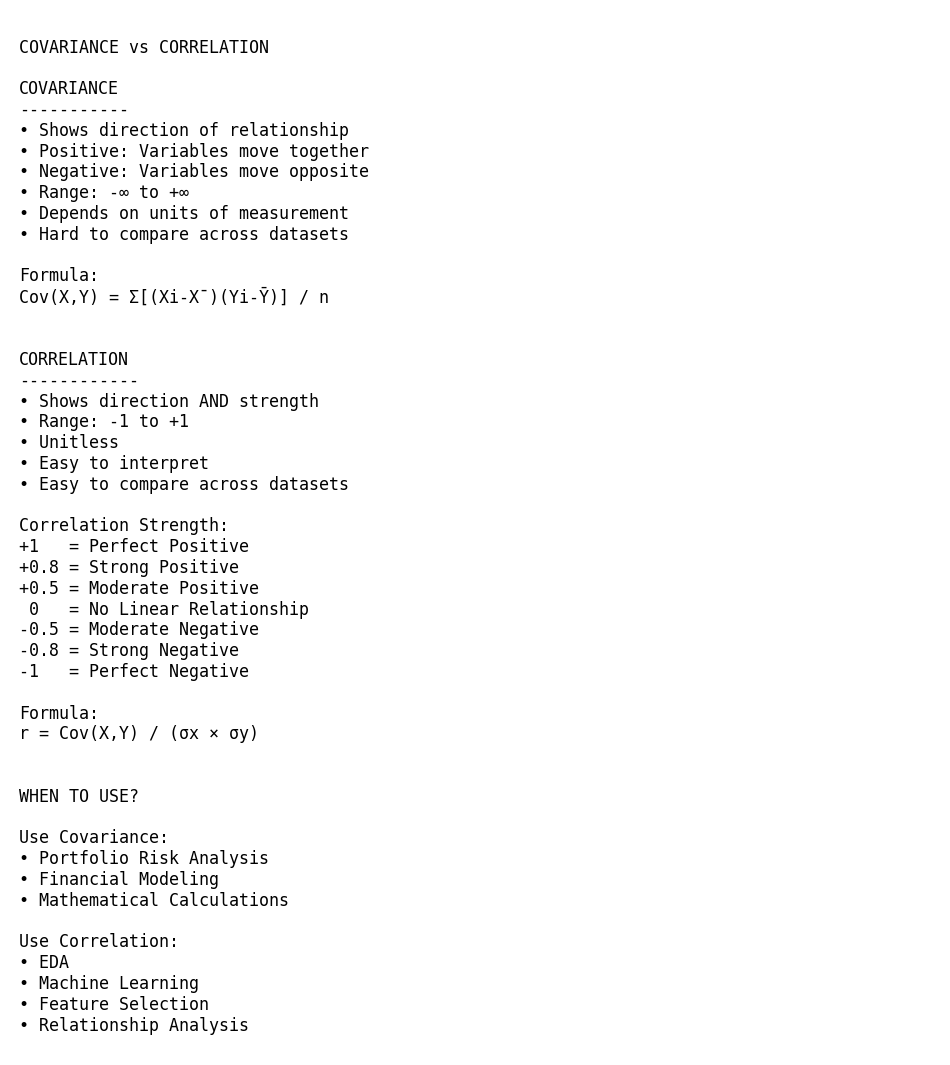

In [32]:
import matplotlib.pyplot as plt

text = """
COVARIANCE vs CORRELATION

COVARIANCE
-----------
• Shows direction of relationship
• Positive: Variables move together
• Negative: Variables move opposite
• Range: -∞ to +∞
• Depends on units of measurement
• Hard to compare across datasets

Formula:
Cov(X,Y) = Σ[(Xi-X̄)(Yi-Ȳ)] / n


CORRELATION
------------
• Shows direction AND strength
• Range: -1 to +1
• Unitless
• Easy to interpret
• Easy to compare across datasets

Correlation Strength:
+1   = Perfect Positive
+0.8 = Strong Positive
+0.5 = Moderate Positive
 0   = No Linear Relationship
-0.5 = Moderate Negative
-0.8 = Strong Negative
-1   = Perfect Negative

Formula:
r = Cov(X,Y) / (σx × σy)


WHEN TO USE?

Use Covariance:
• Portfolio Risk Analysis
• Financial Modeling
• Mathematical Calculations

Use Correlation:
• EDA
• Machine Learning
• Feature Selection
• Relationship Analysis
"""

plt.figure(figsize=(12,10))
plt.text(0.01, 0.99, text, fontsize=12, va='top', family='monospace')
plt.axis('off')

plt.savefig("Covariance_vs_Correlation.png",
            bbox_inches='tight',
            dpi=300)

plt.show()